In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean data
df = pd.read_csv('/Users/madhuramdhanesh/Downloads/tickets_clean.csv')
print("Data loaded:", df.shape)

Data loaded: (8469, 22)


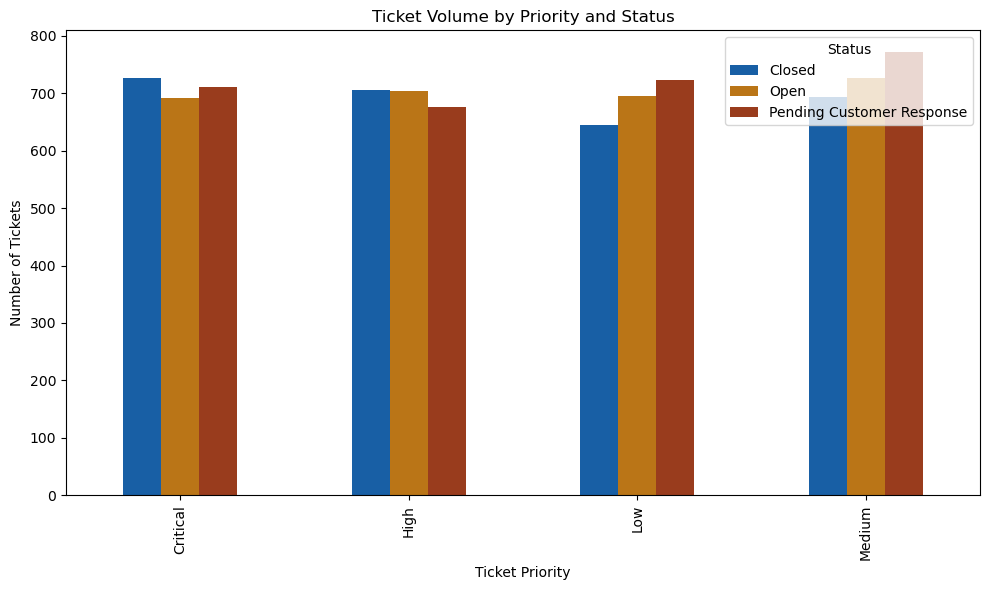

Ticket Status    Closed  Open  Pending Customer Response
Ticket Priority                                         
Critical            726   692                        711
High                705   704                        676
Low                 644   696                        723
Medium              694   727                        771


In [2]:
# Chart 1 - Ticket volume by priority and status
priority_status = df.groupby(['Ticket Priority', 'Ticket Status']).size().unstack()

priority_status.plot(kind='bar', figsize=(10, 6), 
                     color=['#185FA5', '#BA7517', '#993C1D'])
plt.title('Ticket Volume by Priority and Status')
plt.xlabel('Ticket Priority')
plt.ylabel('Number of Tickets')
plt.legend(title='Status')
plt.tight_layout()
plt.savefig('/Users/madhuramdhanesh/Downloads/priority_status.png', dpi=150)
plt.show()

print(priority_status)

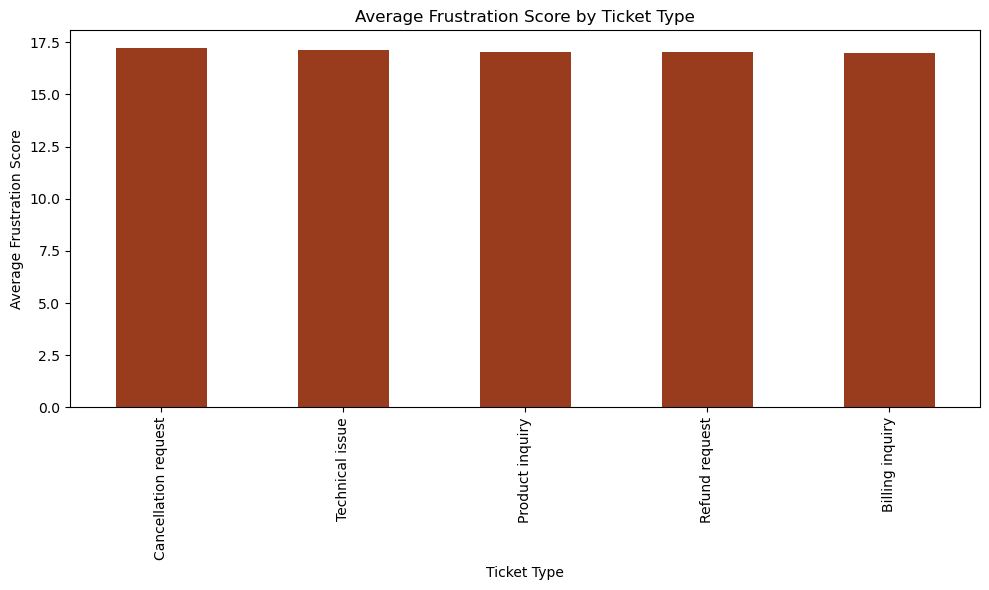

Ticket Type
Cancellation request    17.212979
Technical issue         17.109903
Product inquiry         17.043876
Refund request          17.027968
Billing inquiry         16.984700
Name: frustration_score, dtype: float64


In [3]:
# Chart 2 - Frustration Score by Ticket Type
frustration_by_type = df.groupby('Ticket Type')['frustration_score'].mean().sort_values(ascending=False)

frustration_by_type.plot(kind='bar', figsize=(10, 6), color='#993C1D')
plt.title('Average Frustration Score by Ticket Type')
plt.xlabel('Ticket Type')
plt.ylabel('Average Frustration Score')
plt.tight_layout()
plt.savefig('/Users/madhuramdhanesh/Downloads/frustration_by_type.png', dpi=150)
plt.show()

print(frustration_by_type)

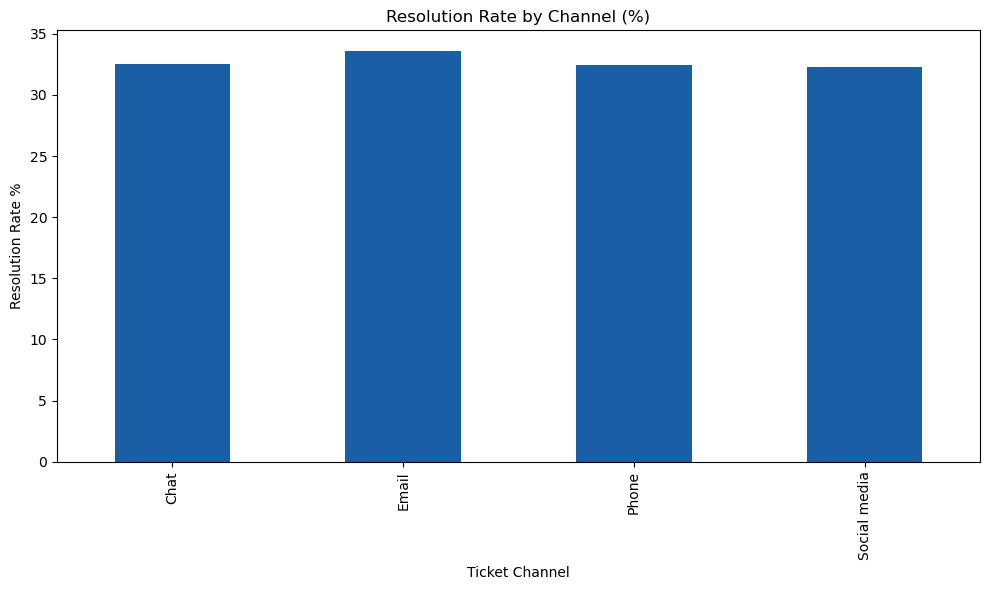

                total_tickets  resolved_tickets  avg_frustration  \
Ticket Channel                                                     
Chat                     2073               674            16.98   
Email                    2143               720            17.06   
Phone                    2132               691            17.13   
Social media             2121               684            17.14   

                resolution_rate  
Ticket Channel                   
Chat                      32.51  
Email                     33.60  
Phone                     32.41  
Social media              32.25  


In [4]:
# Chart 3 - Resolution rate by channel
channel_performance = df.groupby('Ticket Channel').agg(
    total_tickets=('Ticket ID', 'count'),
    resolved_tickets=('is_resolved', 'sum'),
    avg_frustration=('frustration_score', 'mean')
).round(2)

channel_performance['resolution_rate'] = (
    channel_performance['resolved_tickets'] / 
    channel_performance['total_tickets'] * 100
).round(2)

channel_performance['resolution_rate'].plot(
    kind='bar', figsize=(10, 6), color='#185FA5')
plt.title('Resolution Rate by Channel (%)')
plt.xlabel('Ticket Channel')
plt.ylabel('Resolution Rate %')
plt.tight_layout()
plt.savefig('/Users/madhuramdhanesh/Downloads/channel_performance.png', dpi=150)
plt.show()

print(channel_performance)


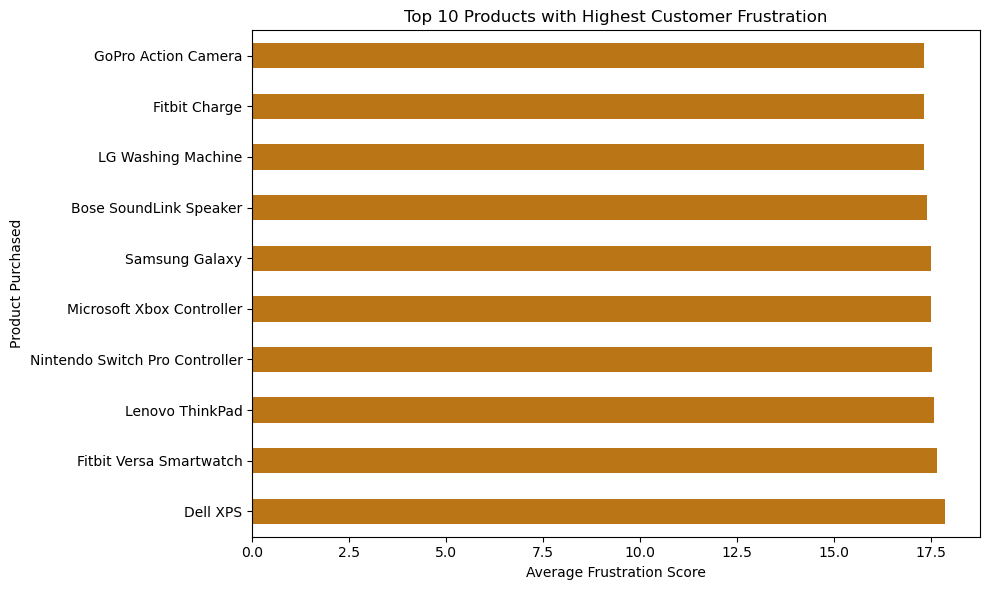

Product Purchased
Dell XPS                          17.864865
Fitbit Versa Smartwatch           17.649215
Lenovo ThinkPad                   17.568306
Nintendo Switch Pro Controller    17.512315
Microsoft Xbox Controller         17.489796
Samsung Galaxy                    17.484536
Bose SoundLink Speaker            17.390863
LG Washing Machine                17.307692
Fitbit Charge                     17.306931
GoPro Action Camera               17.306011
Name: frustration_score, dtype: float64


In [5]:
# Chart 4 - Top 10 products with highest frustration
product_frustration = df.groupby('Product Purchased')['frustration_score'].mean().sort_values(ascending=False).head(10)

product_frustration.plot(kind='barh', figsize=(10, 6), color='#BA7517')
plt.title('Top 10 Products with Highest Customer Frustration')
plt.xlabel('Average Frustration Score')
plt.tight_layout()
plt.savefig('/Users/madhuramdhanesh/Downloads/product_frustration.png', dpi=150)
plt.show()

print(product_frustration)
